# User Journey Funnel Analysis

## Project Overview

A User Journey Funnel represents the path users follow before completing a desired action, such as making a purchase.

In this project, we analyze the following funnel:

Visited Website → Signed Up → Added to Cart → Purchased

At each stage, some users continue while others leave the funnel.

---

## Problem Statement

Businesses often experience user drop-offs before purchase.

The challenge is to identify:

- Where users abandon the journey
- Which devices perform poorly
- Which traffic sources bring high-quality users
- Which locations have better conversion rates

---

## Project Objectives

- Calculate funnel conversion rates
- Identify drop-off points
- Analyze funnel performance by segment
- Build interactive dashboards
- Generate automated reports
- Provide business recommendations

---

## Business Value

This analysis helps organizations:

- Increase revenue
- Improve user experience
- Optimize marketing campaigns
- Reduce abandonment rates
- Make data-driven decisions

In [1]:
# importing required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from ydata_profiling import ProfileReport
from fpdf import FPDF

from dash import Dash
from dash import dcc
from dash import html
from dash.dependencies import Input, Output

import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\User Journey Funnel\data\user_data_updated.csv")
df.head()

,user_id,device,location,traffic_source,visited,signed_up,added_to_cart,purchased,timestamp
0,user_0,mobile,Delhi,social_media,True,False,False,False,2025-05-21 03:01:00
1,user_1,tablet,Delhi,organic_search,True,True,True,True,2025-04-05 07:14:00
2,user_2,desktop,Mumbai,paid_ads,True,False,False,False,2025-03-18 23:06:00
3,user_3,desktop,Hyderabad,social_media,True,True,True,False,2025-05-26 23:57:00
4,user_4,mobile,Bangalore,paid_ads,True,False,False,False,2025-05-09 02:37:00


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10000
Columns: 9


In [4]:
df.columns.tolist()

['user_id',
 'device',
 'location',
 'traffic_source',
 'visited',
 'signed_up',
 'added_to_cart',
 'purchased',
 'timestamp']

In [5]:
df.dtypes

user_id           object
device            object
location          object
traffic_source    object
visited             bool
signed_up           bool
added_to_cart       bool
purchased           bool
timestamp         object
dtype: object

# Understanding the Dataset

Before analysis, it is important to understand:

- Number of records
- Data types
- Unique categories
- Distribution of values

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         10000 non-null  object
 1   device          10000 non-null  object
 2   location        10000 non-null  object
 3   traffic_source  10000 non-null  object
 4   visited         10000 non-null  bool  
 5   signed_up       10000 non-null  bool  
 6   added_to_cart   10000 non-null  bool  
 7   purchased       10000 non-null  bool  
 8   timestamp       10000 non-null  object
dtypes: bool(4), object(5)
memory usage: 429.8+ KB


In [7]:
df.describe(include='all')

,user_id,device,location,traffic_source,visited,signed_up,added_to_cart,purchased,timestamp
count,10000,10000,10000,10000,10000,10000,10000,10000,10000
unique,10000,3,10,6,1,2,2,2,9611
top,user_0,mobile,Mumbai,organic_search,True,False,False,False,2025-03-17 10:48:00
freq,1,5606,1967,2971,10000,5000,8475,9263,3


In [8]:
print("Devices:")
print(df["device"].unique())

print("\nLocations:")
print(df["location"].unique())

print("\nTraffic Sources:")
print(df["traffic_source"].unique())

Devices:
['mobile' 'tablet' 'desktop']

Locations:
['Delhi' 'Mumbai' 'Hyderabad' 'Bangalore' 'Pune' 'Kolkata' 'Chennai'
 'Ahmedabad' 'Indore' 'Jaipur']

Traffic Sources:
['social_media' 'organic_search' 'paid_ads' 'referral' 'direct' 'email']


In [9]:
df["device"].value_counts()

device
mobile     5606
desktop    3433
tablet      961
Name: count, dtype: int64

In [10]:
df["location"].value_counts()

location
Mumbai       1967
Delhi        1762
Bangalore    1517
Hyderabad    1192
Chennai       990
Kolkata       803
Pune          748
Ahmedabad     496
Jaipur        303
Indore        222
Name: count, dtype: int64

In [11]:
df["traffic_source"].value_counts()

traffic_source
organic_search    2971
paid_ads          2515
social_media      2067
email             1002
direct             951
referral           494
Name: count, dtype: int64

In [12]:
df.isnull().sum()

user_id           0
device            0
location          0
traffic_source    0
visited           0
signed_up         0
added_to_cart     0
purchased         0
timestamp         0
dtype: int64

In [13]:
df.fillna("Unknown", inplace=True)

In [14]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)
df.drop_duplicates(inplace=True)

Duplicate Records: 0


In [15]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [16]:
df["timestamp"].dtype

dtype('<M8[ns]')

In [17]:
invalid_purchase = df[
    (df["purchased"] == True) &
    (df["added_to_cart"] == False)
]

print("Invalid Purchase Records:", len(invalid_purchase))

Invalid Purchase Records: 0


In [18]:
invalid_cart = df[
    (df["added_to_cart"] == True) &
    (df["signed_up"] == False)
]

print("Invalid Cart Records:", len(invalid_cart))

Invalid Cart Records: 0


In [19]:
invalid_signup = df[
    (df["signed_up"] == True) &
    (df["visited"] == False)
]

print("Invalid Signup Records:", len(invalid_signup))

Invalid Signup Records: 0


In [20]:
visited = df["visited"].sum()
signed_up = df["signed_up"].sum()
cart = df["added_to_cart"].sum()
purchased = df["purchased"].sum()

funnel_df = pd.DataFrame({
    "Stage": [
        "Visited",
        "Signed Up",
        "Added To Cart",
        "Purchased"
    ],
    "Users": [
        visited,
        signed_up,
        cart,
        purchased
    ]
})

funnel_df

,Stage,Users
0,Visited,10000
1,Signed Up,5000
2,Added To Cart,1525
3,Purchased,737


In [21]:
overall_conversion = (
    purchased / visited
) * 100

print(
    f"Overall Conversion Rate: {overall_conversion:.2f}%"
)

Overall Conversion Rate: 7.37%


In [22]:
dropoff_signup = ((visited - signed_up) / visited) * 100

dropoff_cart = ((signed_up - cart) / signed_up) * 100

dropoff_purchase = ((cart - purchased) / cart) * 100

print(f"Visit → Signup Dropoff: {dropoff_signup:.2f}%")
print(f"Signup → Cart Dropoff: {dropoff_cart:.2f}%")
print(f"Cart → Purchase Dropoff: {dropoff_purchase:.2f}%")

Visit → Signup Dropoff: 50.00%
Signup → Cart Dropoff: 69.50%
Cart → Purchase Dropoff: 51.67%


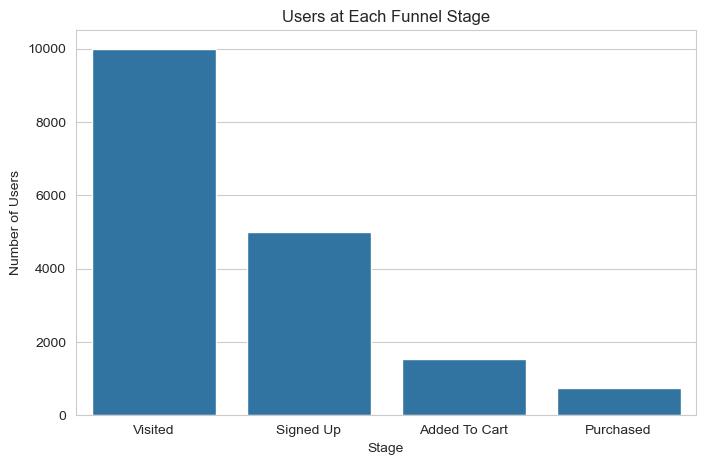

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=funnel_df,
    x="Stage",
    y="Users"
)

plt.title("Users at Each Funnel Stage")
plt.xlabel("Stage")
plt.ylabel("Number of Users")

plt.show()

The funnel chart shows where the largest decline in users occurs.

A sharp decline indicates friction in the customer journey.

In [24]:
device_conversion = df.groupby("device").agg({
    "visited":"sum",
    "purchased":"sum"
})

device_conversion["conversion_rate"] = (
    device_conversion["purchased"] /
    device_conversion["visited"]
) * 100

device_conversion

,visited,purchased,conversion_rate
device,,,
desktop,3433,272,7.923099
mobile,5606,391,6.974670
tablet,961,74,7.700312


In [25]:
traffic_conversion = df.groupby(
    "traffic_source"
).agg({
    "visited":"sum",
    "purchased":"sum"
})

traffic_conversion["conversion_rate"] = (
    traffic_conversion["purchased"] /
    traffic_conversion["visited"]
) * 100

traffic_conversion

,visited,purchased,conversion_rate
traffic_source,,,
direct,951,74,7.781283
email,1002,69,6.886228
organic_search,2971,218,7.337597
paid_ads,2515,186,7.395626
referral,494,42,8.502024
social_media,2067,148,7.160135


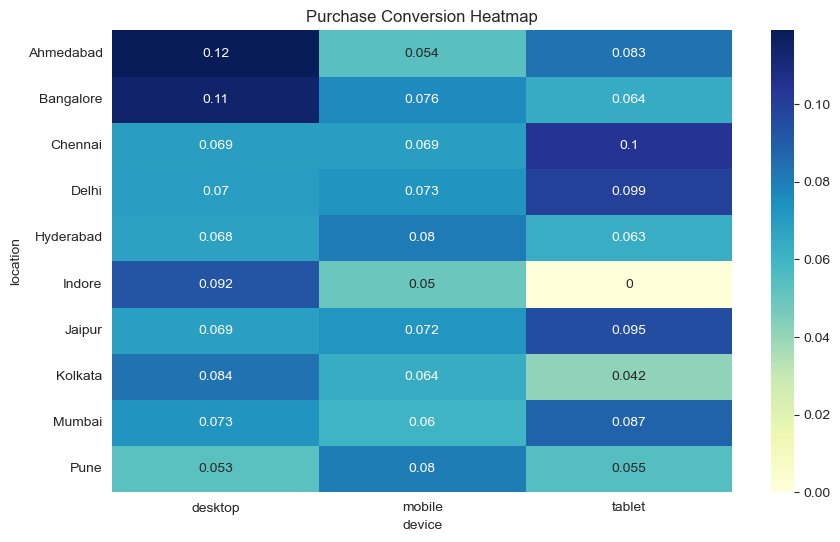

In [26]:
heatmap_data = pd.pivot_table(
    df,
    values="purchased",
    index="location",
    columns="device",
    aggfunc="mean"
)

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu"
)

plt.title(
    "Purchase Conversion Heatmap"
)

plt.show()

# Automated Data Profiling Report

YData Profiling automatically generates a detailed exploratory analysis report.

Benefits:

- Detect missing values
- Identify data quality issues
- View distributions
- Analyze correlations
- Detect duplicates
- Generate summary statistics

This report is useful for quickly understanding a dataset before deeper analysis.

In [27]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title="User Journey Funnel Analysis Report",
    explorative=True
)

profile.to_file("funnel_report.html")

print("Report saved as funnel_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:00<00:00, 90.12it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Report saved as funnel_report.html


In [28]:
profile

## Key Sections to Review

### Overview
Provides dataset dimensions and data quality metrics.

### Variables
Shows distributions of each column.

### Interactions
Highlights relationships between variables.

### Correlations
Useful for understanding behavioral patterns.

### Missing Values
Identifies incomplete records.

### Duplicates
Detects duplicate rows that may impact analysis.

# Interactive KPI Visualizations

Plotly provides interactive charts with:

- Hover tooltips
- Zooming
- Filtering
- Better presentation quality

These charts are ideal for dashboards and stakeholder presentations.

In [29]:
fig = go.Figure(
    go.Funnel(
        y=[
            "Visited",
            "Signed Up",
            "Added To Cart",
            "Purchased"
        ],
        x=[
            visited,
            signed_up,
            cart,
            purchased
        ],
        textinfo="value+percent initial"
    )
)

fig.update_layout(
    title="Overall User Journey Funnel",
    height=600
)

fig.show()

In [30]:
device_plot = device_conversion.reset_index()

fig = px.bar(
    device_plot,
    x="device",
    y="conversion_rate",
    color="conversion_rate",
    title="Conversion Rate by Device",
    labels={
        "device":"Device",
        "conversion_rate":"Conversion Rate (%)"
    }
)

fig.update_traces(
    hovertemplate=
    "<b>%{x}</b><br>" +
    "Conversion Rate: %{y:.2f}%"
)

fig.show()

In [31]:
traffic_plot = traffic_conversion.reset_index()

fig = px.bar(
    traffic_plot,
    x="traffic_source",
    y="conversion_rate",
    color="conversion_rate",
    title="Conversion Rate by Traffic Source",
    labels={
        "traffic_source":"Traffic Source",
        "conversion_rate":"Conversion Rate (%)"
    }
)

fig.update_layout(
    xaxis_tickangle=-30
)

fig.show()

In [32]:
location_conversion = df.groupby(
    "location"
).agg({
    "visited":"sum",
    "purchased":"sum"
})

location_conversion["conversion_rate"] = (
    location_conversion["purchased"] /
    location_conversion["visited"]
) * 100

location_conversion = (
    location_conversion
    .sort_values(
        "conversion_rate",
        ascending=False
    )
    .reset_index()
)

fig = px.bar(
    location_conversion,
    x="location",
    y="conversion_rate",
    color="conversion_rate",
    title="Conversion Rate by Location"
)

fig.show()

In [33]:
heatmap_data = pd.pivot_table(
    df,
    values="purchased",
    index="location",
    columns="device",
    aggfunc="mean"
)

fig = px.imshow(
    heatmap_data,
    text_auto=".2f",
    aspect="auto",
    title="Purchase Conversion Heatmap"
)

fig.show()

# PDF Report Generation

Stakeholders often prefer PDF summaries rather than notebooks.

The report will contain:

- Project title
- Summary statistics
- Key findings
- Visualizations
- Business recommendations

In [34]:
import os
from fpdf import FPDF
from datetime import datetime

folder = r"C:\Users\ASUS\OneDrive\Desktop\User Journey Funnel"

# Step 1: Save all charts

# Funnel Chart
plt.figure(figsize=(8,5))
sns.barplot(data=funnel_df, x="Stage", y="Users")
plt.title("Funnel Stage Users")
plt.savefig(os.path.join(folder, "chart_funnel.png"), bbox_inches="tight")
plt.close()

# Device Conversion
device_conversion["conversion_rate"].plot(kind="bar", figsize=(8,5))
plt.title("Conversion Rate by Device")
plt.ylabel("Conversion Rate (%)")
plt.savefig(os.path.join(folder, "chart_device.png"), bbox_inches="tight")
plt.close()

# Traffic Source Conversion
traffic_conversion["conversion_rate"].plot(kind="bar", figsize=(10,5))
plt.title("Conversion Rate by Traffic Source")
plt.ylabel("Conversion Rate (%)")
plt.savefig(os.path.join(folder, "chart_traffic.png"), bbox_inches="tight")
plt.close()

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu")
plt.title("Location vs Device Conversion")
plt.savefig(os.path.join(folder, "chart_heatmap.png"), bbox_inches="tight")
plt.close()

print("✅ Charts saved!")

# Step 2: Build PDF

pdf = FPDF()
pdf.set_auto_page_break(auto=True, margin=15)

dropoffs = {
    "Visit -> Signup": dropoff_signup,
    "Signup -> Cart": dropoff_cart,
    "Cart -> Purchase": dropoff_purchase
}
biggest_stage = max(dropoffs, key=dropoffs.get)

# Cover Page
pdf.add_page()
pdf.set_font("Helvetica", "B", 22)
pdf.cell(0, 15, "User Journey Funnel Analysis", ln=True, align="C")
pdf.ln(10)
pdf.set_font("Helvetica", "", 14)
pdf.cell(0, 10, f"Generated on: {datetime.now().strftime('%d-%m-%Y')}", ln=True, align="C")
pdf.ln(15)
pdf.multi_cell(0, 10, """
This report analyzes the user journey from
website visit to final purchase.

The objective is to identify conversion
bottlenecks, user drop-off points, and
opportunities to improve business performance.
""")

# Executive Summary
pdf.add_page()
pdf.set_font("Helvetica", "B", 18)
pdf.cell(0, 10, "Executive Summary", ln=True)
pdf.ln(5)
pdf.set_font("Helvetica", "", 12)
pdf.multi_cell(0, 8, f"""
Total Users: {len(df):,}
Total Visitors: {visited:,}
Total Signups: {signed_up:,}
Total Cart Users: {cart:,}
Total Purchases: {purchased:,}

Overall Conversion Rate: {overall_conversion:.2f}%
Visit -> Signup Drop-off: {dropoff_signup:.2f}%
Signup -> Cart Drop-off: {dropoff_cart:.2f}%
Cart -> Purchase Drop-off: {dropoff_purchase:.2f}%
""")
pdf.ln(5)
pdf.set_font("Helvetica", "B", 14)
pdf.cell(0, 10, "Key Findings", ln=True)
pdf.set_font("Helvetica", "", 12)
pdf.multi_cell(0, 8, f"""
1. Largest drop-off occurs at: {biggest_stage}
2. Overall Conversion Rate: {overall_conversion:.2f}%
3. Funnel optimization should focus on reducing abandonment at the highest leakage stage.
""")

# Chart 1
pdf.add_page()
pdf.set_font("Helvetica", "B", 16)
pdf.cell(0, 10, "Chart 1: Funnel Overview", ln=True)
pdf.ln(5)
pdf.image(os.path.join(folder, "chart_funnel.png"), x=15, w=180)
pdf.ln(5)
pdf.set_font("Helvetica", "", 11)
pdf.multi_cell(0, 7, "Insight: This chart shows user progression through the funnel and highlights where users leave before completing a purchase.")

# Chart 2
pdf.add_page()
pdf.set_font("Helvetica", "B", 16)
pdf.cell(0, 10, "Chart 2: Conversion Rate by Device", ln=True)
pdf.ln(5)
pdf.image(os.path.join(folder, "chart_device.png"), x=15, w=180)
pdf.ln(5)
pdf.set_font("Helvetica", "", 11)
pdf.multi_cell(0, 7, "Insight: This chart compares conversion performance across devices and helps identify device-specific optimization opportunities.")

# Chart 3
pdf.add_page()
pdf.set_font("Helvetica", "B", 16)
pdf.cell(0, 10, "Chart 3: Conversion Rate by Traffic Source", ln=True)
pdf.ln(5)
pdf.image(os.path.join(folder, "chart_traffic.png"), x=15, w=180)
pdf.ln(5)
pdf.set_font("Helvetica", "", 11)
pdf.multi_cell(0, 7, "Insight: This chart identifies which traffic sources generate the highest quality users and strongest conversion rates.")

# Chart 4
pdf.add_page()
pdf.set_font("Helvetica", "B", 16)
pdf.cell(0, 10, "Chart 4: Location vs Device Heatmap", ln=True)
pdf.ln(5)
pdf.image(os.path.join(folder, "chart_heatmap.png"), x=10, w=190)
pdf.ln(5)
pdf.set_font("Helvetica", "", 11)
pdf.multi_cell(0, 7, "Insight: The heatmap highlights conversion patterns across different locations and devices.")

# Recommendations
pdf.add_page()
pdf.set_font("Helvetica", "B", 18)
pdf.cell(0, 10, "Business Recommendations", ln=True)
pdf.ln(5)
pdf.set_font("Helvetica", "", 12)
pdf.multi_cell(0, 8, f"""
1. Prioritize reducing drop-offs at: {biggest_stage}
2. Simplify the signup process.
3. Improve product page design and CTA visibility.
4. Optimize checkout experience to reduce cart abandonment.
5. Increase investment in the best performing traffic sources.
6. Improve mobile responsiveness and page load speed.

Expected Benefits:
- Higher conversion rates
- Increased revenue
- Better user experience
- Improved marketing ROI
""")

# Step 3: Save PDF 
pdf.output(os.path.join(folder, "funnel_analysis_report.pdf"))
print("✅ PDF saved to:", folder)

✅ Charts saved!
✅ PDF saved to: C:\Users\ASUS\OneDrive\Desktop\User Journey Funnel


In [35]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from dash import Dash, dcc, html, Input, Output

# Precompute all data needed by the dashboard

# Location conversion
location_conversion = df.groupby("location").agg(
    visited=("visited", "sum"),
    purchased=("purchased", "sum")
).reset_index()
location_conversion["conversion_rate"] = (
    location_conversion["purchased"] / location_conversion["visited"]
) * 100

# Device conversion
device_conv = df.groupby("device").agg(
    visited=("visited", "sum"),
    purchased=("purchased", "sum")
).reset_index()
device_conv["conversion_rate"] = (
    device_conv["purchased"] / device_conv["visited"]
) * 100

# Traffic conversion
traffic_conv = df.groupby("traffic_source").agg(
    visited=("visited", "sum"),
    purchased=("purchased", "sum")
).reset_index()
traffic_conv["conversion_rate"] = (
    traffic_conv["purchased"] / traffic_conv["visited"]
) * 100

# Heatmap data
heatmap_pivot = pd.pivot_table(
    df,
    values="purchased",
    index="location",
    columns="device",
    aggfunc="mean"
) * 100

# Monthly trend
df["month"] = pd.to_datetime(df["timestamp"]).dt.to_period("M").astype(str)
monthly = df.groupby("month").agg(
    visitors=("visited", "sum"),
    purchases=("purchased", "sum")
).reset_index()
monthly["conversion_rate"] = (monthly["purchases"] / monthly["visitors"]) * 100

# Dropdown options
device_options   = [{"label": "All Devices",  "value": "All"}] + [{"label": d, "value": d} for d in df["device"].unique()]
traffic_options  = [{"label": "All Sources",  "value": "All"}] + [{"label": t, "value": t} for t in df["traffic_source"].unique()]
location_options = [{"label": "All Locations","value": "All"}] + [{"label": l, "value": l} for l in sorted(df["location"].unique())]

# Colour theme 
DARK    = "#0f1724"
NAVY    = "#1a2a4a"
BLUE    = "#2563eb"
TEAL    = "#0ea5e9"
ACCENT  = "#f59e0b"
GREEN   = "#10b981"
RED     = "#ef4444"
LIGHT   = "#e2e8f0"
MUTED   = "#94a3b8"
WHITE   = "#ffffff"

# KPI card helper 
def kpi_card(title, value, color=TEAL):
    return html.Div([
        html.P(title, style={"margin": "0", "fontSize": "12px", "color": MUTED, "letterSpacing": "1px", "textTransform": "uppercase"}),
        html.H2(value, style={"margin": "4px 0 0 0", "fontSize": "28px", "color": color, "fontWeight": "bold"}),
    ], style={
        "background": NAVY,
        "borderRadius": "10px",
        "padding": "18px 24px",
        "flex": "1",
        "minWidth": "140px",
        "borderLeft": f"4px solid {color}",
    })

# App layout
app = Dash(__name__)
app.title = "Funnel Dashboard"

app.layout = html.Div(style={"backgroundColor": DARK, "minHeight": "100vh", "fontFamily": "Segoe UI, Arial, sans-serif", "color": WHITE}, children=[

    # Header
    html.Div([
        html.H1("🔥 User Journey Funnel Dashboard",
                style={"margin": "0", "fontSize": "26px", "color": WHITE, "fontWeight": "bold"}),
        html.P("Conversion Analytics — Mar to May 2025",
               style={"margin": "4px 0 0 0", "color": MUTED, "fontSize": "13px"}),
    ], style={"background": NAVY, "padding": "20px 32px", "borderBottom": f"2px solid {BLUE}"}),

    # Filters
    html.Div([
        html.Div([
            html.Label("Device", style={"color": MUTED, "fontSize": "12px", "marginBottom": "4px", "display": "block"}),
            dcc.Dropdown(
                id="filter-device",
                options=device_options,
                value="All",
                clearable=False,
                style={"backgroundColor": NAVY, "color": DARK, "borderColor": BLUE}
            ),
        ], style={"flex": "1", "minWidth": "160px"}),

        html.Div([
            html.Label("Traffic Source", style={"color": MUTED, "fontSize": "12px", "marginBottom": "4px", "display": "block"}),
            dcc.Dropdown(
                id="filter-traffic",
                options=traffic_options,
                value="All",
                clearable=False,
                style={"backgroundColor": NAVY, "color": DARK, "borderColor": BLUE}
            ),
        ], style={"flex": "1", "minWidth": "160px"}),

        html.Div([
            html.Label("Location", style={"color": MUTED, "fontSize": "12px", "marginBottom": "4px", "display": "block"}),
            dcc.Dropdown(
                id="filter-location",
                options=location_options,
                value="All",
                clearable=False,
                style={"backgroundColor": NAVY, "color": DARK, "borderColor": BLUE}
            ),
        ], style={"flex": "1", "minWidth": "160px"}),

    ], style={"display": "flex", "gap": "16px", "padding": "20px 32px", "background": DARK, "flexWrap": "wrap"}),

    # KPI Cards
    html.Div(id="kpi-cards",
             style={"display": "flex", "gap": "16px", "padding": "0 32px 20px", "flexWrap": "wrap"}),

    # Row 1: Funnel + Monthly Trend 
    html.Div([
        html.Div(dcc.Graph(id="chart-funnel"),
                 style={"flex": "1", "minWidth": "300px", "background": NAVY, "borderRadius": "10px", "padding": "8px"}),
        html.Div(dcc.Graph(id="chart-monthly"),
                 style={"flex": "1.4", "minWidth": "300px", "background": NAVY, "borderRadius": "10px", "padding": "8px"}),
    ], style={"display": "flex", "gap": "16px", "padding": "0 32px 16px", "flexWrap": "wrap"}),

    # Row 2: Device + Traffic 
    html.Div([
        html.Div(dcc.Graph(id="chart-device"),
                 style={"flex": "1", "minWidth": "300px", "background": NAVY, "borderRadius": "10px", "padding": "8px"}),
        html.Div(dcc.Graph(id="chart-traffic"),
                 style={"flex": "1", "minWidth": "300px", "background": NAVY, "borderRadius": "10px", "padding": "8px"}),
    ], style={"display": "flex", "gap": "16px", "padding": "0 32px 16px", "flexWrap": "wrap"}),

    # Row 3: Location bar + Heatmap
    html.Div([
        html.Div(dcc.Graph(id="chart-location"),
                 style={"flex": "1", "minWidth": "300px", "background": NAVY, "borderRadius": "10px", "padding": "8px"}),
        html.Div(dcc.Graph(id="chart-heatmap"),
                 style={"flex": "1.2", "minWidth": "300px", "background": NAVY, "borderRadius": "10px", "padding": "8px"}),
    ], style={"display": "flex", "gap": "16px", "padding": "0 32px 24px", "flexWrap": "wrap"}),

])

# Chart theme helper 
def dark_layout(title):
    return dict(
        title=dict(text=title, font=dict(color=WHITE, size=14)),
        paper_bgcolor=NAVY,
        plot_bgcolor=NAVY,
        font=dict(color=LIGHT),
        margin=dict(l=40, r=20, t=45, b=40),
        xaxis=dict(gridcolor="#1e3a5f", zerolinecolor="#1e3a5f"),
        yaxis=dict(gridcolor="#1e3a5f", zerolinecolor="#1e3a5f"),
    )

# Callback
@app.callback(
    Output("kpi-cards",     "children"),
    Output("chart-funnel",  "figure"),
    Output("chart-monthly", "figure"),
    Output("chart-device",  "figure"),
    Output("chart-traffic", "figure"),
    Output("chart-location","figure"),
    Output("chart-heatmap", "figure"),
    Input("filter-device",  "value"),
    Input("filter-traffic", "value"),
    Input("filter-location","value"),
)
def update_dashboard(sel_device, sel_traffic, sel_location):

    # Apply filters
    filtered = df.copy()
    if sel_device   != "All": filtered = filtered[filtered["device"]         == sel_device]
    if sel_traffic  != "All": filtered = filtered[filtered["traffic_source"] == sel_traffic]
    if sel_location != "All": filtered = filtered[filtered["location"]       == sel_location]

    # Recalculate KPIs
    v  = int(filtered["visited"].sum())
    s  = int(filtered["signed_up"].sum())
    c  = int(filtered["added_to_cart"].sum())
    p  = int(filtered["purchased"].sum())
    cr = (p / v * 100) if v > 0 else 0

    # KPI Cards
    kpis = html.Div([
        kpi_card("Total Visitors",   f"{v:,}",      TEAL),
        kpi_card("Sign-Ups",         f"{s:,}",      BLUE),
        kpi_card("Cart Adds",        f"{c:,}",      ACCENT),
        kpi_card("Purchases",        f"{p:,}",      GREEN),
        kpi_card("Conversion Rate",  f"{cr:.2f}%",  RED if cr < 5 else GREEN),
    ], style={"display": "flex", "gap": "16px", "flexWrap": "wrap", "width": "100%"})

    # Funnel chart
    fig_funnel = go.Figure(go.Funnel(
        y=["Visited", "Signed Up", "Added to Cart", "Purchased"],
        x=[v, s, c, p],
        textinfo="value+percent initial",
        marker=dict(color=[BLUE, TEAL, ACCENT, GREEN]),
        connector=dict(line=dict(color=MUTED, width=1)),
    ))
    fig_funnel.update_layout(**dark_layout("User Journey Funnel"))

    # Monthly trend
    mon = filtered.copy()
    mon["month"] = pd.to_datetime(mon["timestamp"]).dt.to_period("M").astype(str)
    mon_grp = mon.groupby("month").agg(
        visitors=("visited","sum"), purchases=("purchased","sum")
    ).reset_index()
    mon_grp["conv"] = (mon_grp["purchases"] / mon_grp["visitors"] * 100).fillna(0)

    fig_monthly = go.Figure()
    fig_monthly.add_trace(go.Bar(x=mon_grp["month"], y=mon_grp["visitors"],
                                  name="Visitors", marker_color=BLUE, opacity=0.7))
    fig_monthly.add_trace(go.Bar(x=mon_grp["month"], y=mon_grp["purchases"],
                                  name="Purchases", marker_color=GREEN))
    fig_monthly.add_trace(go.Scatter(x=mon_grp["month"], y=mon_grp["conv"],
                                      name="Conv %", yaxis="y2",
                                      line=dict(color=ACCENT, width=2.5),
                                      marker=dict(size=7)))
    fig_monthly.update_layout(
        **dark_layout("Monthly Trend"),
        barmode="overlay",
        yaxis2=dict(overlaying="y", side="right", showgrid=False,
                    tickfont=dict(color=ACCENT), title=dict(text="Conv %", font=dict(color=ACCENT))),
        legend=dict(bgcolor=NAVY, font=dict(color=WHITE)),
    )

    # Device bar
    dev = filtered.groupby("device").agg(
        visited=("visited","sum"), purchased=("purchased","sum")
    ).reset_index()
    dev["conv"] = (dev["purchased"] / dev["visited"] * 100).fillna(0)

    fig_device = px.bar(dev, x="device", y="conv",
                        color="conv", color_continuous_scale=[[0, NAVY],[0.5, BLUE],[1, TEAL]],
                        text=dev["conv"].apply(lambda x: f"{x:.1f}%"),
                        labels={"device":"Device","conv":"Conv Rate (%)"})
    fig_device.update_traces(textposition="outside", textfont_color=WHITE)
    fig_device.update_layout(**dark_layout("Conversion Rate by Device"),
                              coloraxis_showscale=False)

    #Traffic source bar
    traf = filtered.groupby("traffic_source").agg(
        visited=("visited","sum"), purchased=("purchased","sum")
    ).reset_index()
    traf["conv"] = (traf["purchased"] / traf["visited"] * 100).fillna(0)
    traf = traf.sort_values("conv", ascending=True)

    fig_traffic = px.bar(traf, x="conv", y="traffic_source", orientation="h",
                         color="conv", color_continuous_scale=[[0, NAVY],[0.5, TEAL],[1, ACCENT]],
                         text=traf["conv"].apply(lambda x: f"{x:.1f}%"),
                         labels={"traffic_source":"Source","conv":"Conv Rate (%)"})
    fig_traffic.update_traces(textposition="outside", textfont_color=WHITE)
    fig_traffic.update_layout(**dark_layout("Conversion by Traffic Source"),
                               coloraxis_showscale=False)

    # Location bar
    loc = filtered.groupby("location").agg(
        visited=("visited","sum"), purchased=("purchased","sum")
    ).reset_index()
    loc["conv"] = (loc["purchased"] / loc["visited"] * 100).fillna(0)
    loc = loc.sort_values("conv", ascending=False)

    fig_location = px.bar(loc, x="location", y="conv",
                          color="conv", color_continuous_scale=[[0, NAVY],[0.5, BLUE],[1, GREEN]],
                          text=loc["conv"].apply(lambda x: f"{x:.1f}%"),
                          labels={"location":"City","conv":"Conv Rate (%)"})
    fig_location.update_traces(textposition="outside", textfont_color=WHITE)
    fig_location.update_layout(**dark_layout("Conversion Rate by Location"),
                                coloraxis_showscale=False)

    # Heatmap
    heat = pd.pivot_table(filtered, values="purchased",
                          index="location", columns="device", aggfunc="mean").fillna(0) * 100
    fig_heatmap = px.imshow(heat, text_auto=".1f", aspect="auto",
                             color_continuous_scale=[[0,"#0f1724"],[0.5,"#2563eb"],[1,"#10b981"]],
                             labels=dict(color="Conv %"))
    fig_heatmap.update_layout(**dark_layout("Location × Device Heatmap"))

    return kpis, fig_funnel, fig_monthly, fig_device, fig_traffic, fig_location, fig_heatmap


# Run 
if __name__ == "__main__":
    app.run(debug=False, port=8050)